# Data Analysis
This notebook is used to analyze the data collected from live runs. It includes various visualizations and statistical analyses to understand the performance of the runner

## TOC:
* [Clean Data](#cleaning-data)
* [Performance from Specific Runs](#performance-from-specific-runs)
* [Simulation vs Reality](#simulation-vs-reality)

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

run_data = "running_simulation_data/01_runs/2026-04-06_13-50"
simulation = "testing_random.parquet/simulation_results.parquet"
# output_data = "rust_sim/results.parquet"

## Test

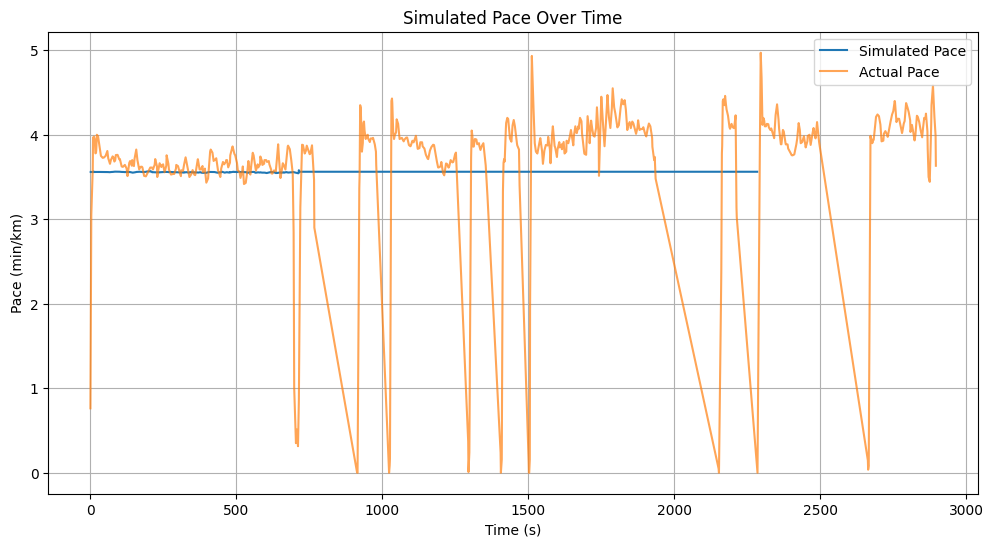

In [3]:
df_run = pd.read_parquet(run_data + "/streams.parquet").iloc[1:]
df_sim = pd.read_parquet(simulation)

# go from smallest time to largest time for runner 0
df_sim = df_sim[df_sim["runner_id"] == 0].sort_values("time_s")

# convert datetime to seconds for both dataframes
df_run["time_s"] = (df_run["time_datetime"] - df_run["time_datetime"].iloc[0]).dt.total_seconds()

# plot the simulated pace over time
plt.figure(figsize=(12, 6))
plt.plot(df_sim["time_s"], df_sim["velocity_mps"], label="Simulated Pace")
plt.plot(df_run["time_s"], df_run["velocity_mps"], label="Actual Pace", alpha=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Pace (min/km)")
plt.title("Simulated Pace Over Time")
plt.legend()
plt.grid()
plt.show()